In [1]:
# COLAB SETUP

%cd /content
!rm -rf /content/proto-tsrl
!git clone https://github.com/haiyan-wang/proto-tsrl.git /content/proto-tsrl
%cd /content/proto-tsrl

from google.colab import drive
drive.mount('/content/drive')

import sys
import os

project_root = os.getcwd()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(project_root)

/content
Cloning into '/content/proto-tsrl'...
remote: Enumerating objects: 1007, done.
remote: Counting objects: 100% (199/199), done.
remote: Compressing objects: 100% (156/156), done.
remote: Total 1007 (delta 118), reused 73 (delta 43), pack-reused 808 (from 1)
Receiving objects: 100% (1007/1007), 54.86 MiB | 21.42 MiB/s, done.
Resolving deltas: 100% (593/593), done.
/content/proto-tsrl
Mounted at /content/drive
/content/proto-tsrl


In [3]:
!pip install pacmap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 30.7 MB/s eta 0:00:00


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
plt.rcParams.update({
    "font.family": "cmr10",
    "mathtext.fontset": "cm",
    "text.usetex": False,
    "axes.unicode_minus": False
})

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix

import pacmap

from src.utils.training_utils import _pairwise_cos_sim, _extended_forward
from src.utils.sampling_utils import TimeSeriesDataset
from src.models.univariate_model import UnivariateModel
from src.utils.ppg_data_utils import *

In [5]:
# SETTINGS

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# device
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(DEVICE)

# data quality
INCLUDE_CLEAN_DATA = True
INCLUDE_SEMINOISY_DATA = True
INCLUDE_NOISY_DATA = False
TRAIN_SET_SIZE = int(1e4)
DATA_PATH = '/content/drive/MyDrive/Duke/Senior Year/Thesis/data'

# logging
SAVE_DIR = "/content/drive/MyDrive/Duke/Senior Year/Thesis/experiments/ppg"

# architecture
REPR_DIMS = [300]
MODELS = {}
for dim in REPR_DIMS:
    model_list = {}

    # unsupervised pretraining checkpoints
    ckpt_dir = f"{SAVE_DIR}/checkpoints_deep/dim{dim}"
    for ckpt_file in os.listdir(ckpt_dir):
        epoch = ckpt_file[len('prototsrl_'):-3]
        ckpt = torch.load(f"{ckpt_dir}/{ckpt_file}", map_location = "cpu")
        MODEL = UnivariateModel(representation_dimension = dim)
        MODEL.load_state_dict(ckpt)
        MODEL = MODEL.to(DEVICE)
        if torch.cuda.device_count() > 1:
            MODEL = nn.DataParallel(MODEL)
        MODEL.eval()

        model_list[epoch] = MODEL

    # sft checkpoints
    ckpt_dir = f"{SAVE_DIR}/checkpoints_deep_sft/dim{dim}"
    for ckpt_file in os.listdir(ckpt_dir):
        epoch_num = int(ckpt_file[len('prototsrl_sft_epoch'):-3]) + 55 # string manipulation weirdness - 55 pretraining epochs + current sft epoch
        ckpt = torch.load(f"{ckpt_dir}/{ckpt_file}", map_location = "cpu")
        representer_state_dict = {k[len("representer."):]: v for k, v in ckpt.items() if k.startswith("representer.")}
        MODEL = UnivariateModel(representation_dimension = dim)
        MODEL.load_state_dict(representer_state_dict)
        MODEL = MODEL.to(DEVICE)
        if torch.cuda.device_count() > 1:
            MODEL = nn.DataParallel(MODEL)
        MODEL.eval()

        model_list[f'epoch{epoch_num}'] = MODEL

    MODELS[dim] = model_list

cuda:0


In [ ]:
# LOAD DATA

'''
# DO NOT RERUN - TRAIN AND SFT DATA ARE ALREADY SAVED FOR FASTER LOADING
X_train, y_train = load_data(
    file_path = DATA_PATH,
    clean = INCLUDE_CLEAN_DATA,
    seminoisy = INCLUDE_SEMINOISY_DATA,
    noisy = INCLUDE_NOISY_DATA,
    dataset = 'train',
    return_labels = True
)
indices = np.random.default_rng(SEED).permutation(X_train.shape[0])
X_train, y_train = X_train[indices][:TRAIN_SET_SIZE], y_train[indices][:TRAIN_SET_SIZE]
'''

X_train = np.loadtxt(f'{DATA_PATH}/ppg_X_train.csv', delimiter = ',')
y_train = np.loadtxt(f'{DATA_PATH}/ppg_y_train.csv', delimiter = ',')
X_train, y_train = X_train[:TRAIN_SET_SIZE], y_train[:TRAIN_SET_SIZE] # random seed is the same as the one that generated this split
X_train = X_train[:, :, np.newaxis]

X_test, y_test = load_data(
    file_path = DATA_PATH,
    clean = INCLUDE_CLEAN_DATA,
    seminoisy = INCLUDE_SEMINOISY_DATA,
    noisy = INCLUDE_NOISY_DATA,
    dataset = 'test',
    return_labels = True
)

# RESHAPE HERE WHEN collate_fn = None
X_train, X_test = np.transpose(X_train, (0, 2, 1)), np.transpose(X_test, (0, 2, 1))

print(f'X_train shape: {X_train.shape}')
print(f'Train set positive samples: {np.sum(y_train)}')
print(f'X_test shape: {X_test.shape}')
print(f'Test set positive samples: {np.sum(y_test)}')

X_train shape: (10000, 1, 800)
Train set positive samples: 3702.0
X_test shape: (5278, 1, 800)
Test set positive samples: 747


/tmp/ipykernel_2449/3644955429.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, axs = plt.subplots(1, 2, figsize = (16, 5), tight_layout = True)


Text(0.5, 1.0, 'AFib')

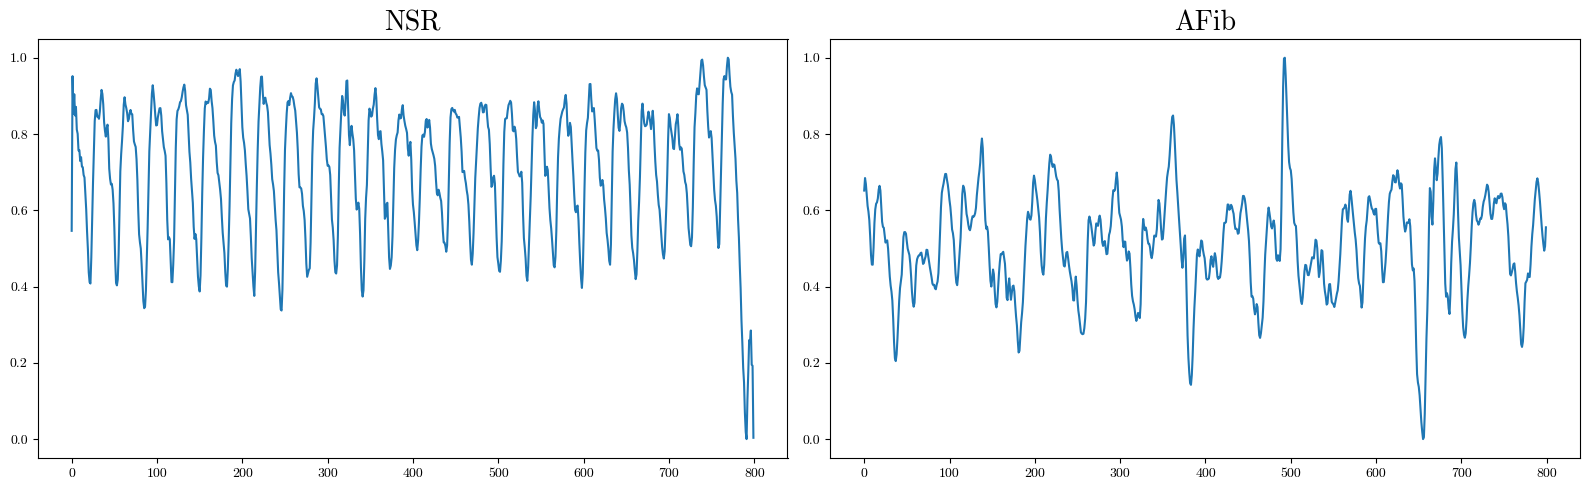

In [ ]:
fig, axs = plt.subplots(1, 2, figsize = (16, 5), tight_layout = True)

axs[0].plot([*range(800)], np.squeeze(np.transpose(X_train[2])))
axs[0].set_title('NSR', fontsize = 20)
axs[1].plot([*range(800)], np.squeeze(np.transpose(X_train[-3])))
axs[1].set_title('AFib', fontsize = 20)

In [ ]:
# GENERATE REPRESENTATIONS

def batched_inference(model, X, device, batch_size = 128):

    X_tensor = torch.tensor(X, dtype = torch.float32)
    loader = DataLoader(TensorDataset(X_tensor), batch_size = batch_size, shuffle = False)

    outputs = []
    with torch.inference_mode():
        for (xb,) in loader:
            xb = xb.to(device, non_blocking = True)
            yb = model(xb)
            outputs.append(yb.cpu())
            del xb, yb
            torch.cuda.empty_cache()

    return torch.cat(outputs, dim = 0).numpy()


if not os.path.exists(f'{SAVE_DIR}/test_reprs_deep/prototsrl{dim}-repr-train.csv'): # check if this has already been run
    for dim in REPR_DIMS:
        # pretrained model
        model = MODELS[dim]['epoch55']
        repr_train = batched_inference(model, X_train, DEVICE)
        repr_test = batched_inference(model, X_test, DEVICE)
        np.savetxt(f'{SAVE_DIR}/test_reprs_deep/prototsrl{dim}-repr-train.csv', repr_train, delimiter = ',')
        np.savetxt(f'{SAVE_DIR}/test_reprs_deep/prototsrl{dim}-repr-test.csv', repr_test, delimiter = ',')

        # finetuned model
        model = MODELS[dim]['epoch80']
        repr_train = batched_inference(model, X_train, DEVICE)
        repr_test = batched_inference(model, X_test, DEVICE)
        np.savetxt(f'{SAVE_DIR}/test_reprs_deep/prototsrl{dim}-sft-repr-train.csv', repr_train, delimiter = ',')
        np.savetxt(f'{SAVE_DIR}/test_reprs_deep/prototsrl{dim}-sft-repr-test.csv', repr_test, delimiter = ',')

In [ ]:
# LOAD TRAIN AND TEST SET REPRESENTATIONS AND CREATE DATALOADERS

repr = {}
for dim in REPR_DIMS:
    repr[dim] = {}
    for repr_set in ['train', 'test']:
        repr[dim][repr_set] = pd.read_csv(f'{SAVE_DIR}/test_reprs_deep/prototsrl{dim}-repr-{repr_set}.csv', header = None).values
        repr[dim][f'{repr_set}-sft'] = pd.read_csv(f'{SAVE_DIR}/test_reprs_deep/prototsrl{dim}-sft-repr-{repr_set}.csv', header = None).values

# Convert to tensors
y_tensors = {}
y_tensors['train'] = torch.tensor(y_train, dtype = torch.float32).unsqueeze(1)
y_tensors['test'] = torch.tensor(y_test, dtype = torch.float32).unsqueeze(1)

repr_loaders = {}
for dim in REPR_DIMS:
    repr_loaders[dim] = {}
    for repr_set in ['train', 'test']:
        X_tensor = torch.tensor(repr[dim][repr_set], dtype = torch.float32)
        X_dataset = TensorDataset(X_tensor, y_tensors[repr_set])
        X_tensor_sft = torch.tensor(repr[dim][f'{repr_set}-sft'], dtype = torch.float32)
        X_dataset_sft = TensorDataset(X_tensor_sft, y_tensors[repr_set])
        if repr_set == 'train':
            repr_loaders[dim][repr_set] = DataLoader(X_dataset, batch_size = 256, shuffle = True)
            repr_loaders[dim][f'{repr_set}-sft'] = DataLoader(X_dataset_sft, batch_size = 256, shuffle = True)
        else:
            repr_loaders[dim][repr_set] = DataLoader(X_dataset, batch_size = X_tensor.size(0), shuffle = False)
            repr_loaders[dim][f'{repr_set}-sft'] = DataLoader(X_dataset_sft, batch_size = X_tensor_sft.size(0), shuffle = False)

# Classification Tasks

In [ ]:
# SIMPLE MODELS

lr_clf = LogisticRegression(max_iter = 500, random_state = SEED)
dt_clf = DecisionTreeClassifier(min_samples_split = 5)
rf_clf = RandomForestClassifier(n_estimators = 100)

sample_weights = compute_sample_weight(class_weight = "balanced", y = y_train)

for dim in REPR_DIMS:
    print(f'===== {dim} dimensional representations =====')

    df_train, df_test = repr[dim]['train'], repr[dim]['test']
    ss = StandardScaler().fit(df_train)
    df_train, df_test = ss.transform(df_train), ss.transform(df_test)

    lr_clf.fit(df_train, y_train) #, sample_weight = sample_weights)
    dt_clf.fit(df_train, y_train) #, sample_weight = sample_weights)
    rf_clf.fit(df_train, y_train) #, sample_weight = sample_weights)

    y_pred_lr = lr_clf.predict(df_test)
    y_pred_dt = dt_clf.predict(df_test)
    y_pred_rf = rf_clf.predict(df_test)

    acc_lr = accuracy_score(y_test, y_pred_lr)
    acc_dt = accuracy_score(y_test, y_pred_dt)
    acc_rf = accuracy_score(y_test, y_pred_rf)

    print(f'acc_lr = {round(acc_lr, 3)} | acc_dt = {round(acc_dt, 3)} | acc_rf = {round(acc_rf, 3)}')
    print('LR')
    print(confusion_matrix(y_test, y_pred_lr))
    print('DT')
    print(confusion_matrix(y_test, y_pred_dt))
    print('RF')
    print(confusion_matrix(y_test, y_pred_rf))

    print(f'===== {dim} dimensional representations (SFT) =====')

    df_train, df_test = repr[dim]['train-sft'], repr[dim]['test-sft']
    ss = StandardScaler().fit(df_train)
    df_train, df_test = ss.transform(df_train), ss.transform(df_test)

    lr_clf.fit(df_train, y_train) #, sample_weight = sample_weights)
    dt_clf.fit(df_train, y_train) #, sample_weight = sample_weights)
    rf_clf.fit(df_train, y_train) #, sample_weight = sample_weights)

    y_pred_lr = lr_clf.predict(df_test)
    y_pred_dt = dt_clf.predict(df_test)
    y_pred_rf = rf_clf.predict(df_test)

    acc_lr = accuracy_score(y_test, y_pred_lr)
    acc_dt = accuracy_score(y_test, y_pred_dt)
    acc_rf = accuracy_score(y_test, y_pred_rf)

    print(f'acc_lr = {round(acc_lr, 3)} | acc_dt = {round(acc_dt, 3)} | acc_rf = {round(acc_rf, 3)}')
    print('LR')
    print(confusion_matrix(y_test, y_pred_lr))
    print('DT')
    print(confusion_matrix(y_test, y_pred_dt))
    print('RF')
    print(confusion_matrix(y_test, y_pred_rf))

===== 300 dimensional representations =====
acc_lr = 0.679 | acc_dt = 0.702 | acc_rf = 0.767
LR
[[2992 1539]
 [ 154  593]]
DT
[[3052 1479]
 [  94  653]]
RF
[[3373 1158]
 [  71  676]]
===== 300 dimensional representations (SFT) =====
acc_lr = 0.868 | acc_dt = 0.847 | acc_rf = 0.86
LR
[[3840  691]
 [   6  741]]
DT
[[3730  801]
 [   9  738]]
RF
[[3796  735]
 [   4  743]]


In [ ]:
# MLP

class mlp_clf(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, input_dim*2),
            nn.ReLU(),
            nn.Linear(input_dim*2, input_dim*4),
            nn.ReLU(),
            nn.Linear(input_dim*4, input_dim*2),
            nn.ReLU(),
            nn.Linear(input_dim*2, 1)
        )

    def forward(self, x):
        return self.net(x)  # logits

def mlpclf_train(
        model,
        dataloader,
        device,
        criterion,
        optimizer,
        n_epochs,
        log_interval = 10
    ):

    for epoch in range(n_epochs):
        model.train()
        running_loss = 0.0

        for xb, yb in dataloader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)

        epoch_loss = running_loss / len(dataloader.dataset)

        if (epoch+1) % log_interval == 0:
            print(f"Epoch {epoch+1:02d}/{n_epochs} - Train Loss: {epoch_loss:.4f}")

def mlpclf_eval(
        model,
        dataloader,
        device
    ):

    model.eval()

    all_probs = []
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for xb, yb in dataloader:
            xb = xb.to(device)
            logits = model(xb)
            probs = torch.sigmoid(logits)

            preds = (probs >= 0.5).float()

            all_probs.extend(probs.cpu().numpy().ravel())
            all_preds.extend(preds.cpu().numpy().ravel())
            all_targets.extend(yb.numpy().ravel())

    all_probs = np.array(all_probs)
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)

    print(f"Accuracy          : {accuracy_score(all_targets, all_preds):.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(all_targets, all_preds))

In [ ]:
mlps = {}
opts = {}
for dim in REPR_DIMS:
    mlps[dim] = mlp_clf(input_dim = dim).to(DEVICE)
    opts[dim] = torch.optim.Adam(mlps[dim].parameters(), lr = 1e-3)

n_neg, n_pos = np.sum(y_train == 0), np.sum(y_train == 1)
pos_weight = torch.tensor([n_neg / n_pos], dtype = torch.float32).to(DEVICE)
criterion = nn.BCEWithLogitsLoss() # pos_weight = pos_weight)

In [ ]:
for dim in REPR_DIMS:
    print(f'===== {dim}D =====')
    mlpclf_train(
        model = mlps[dim],
        dataloader = repr_loaders[dim]['train'],
        device = DEVICE,
        criterion = criterion,
        optimizer = opts[dim],
        n_epochs = 150
    )

    print(f'===== {dim}D (SFT) =====')
    mlpclf_train(
        model = mlps[dim],
        dataloader = repr_loaders[dim]['train-sft'],
        device = DEVICE,
        criterion = criterion,
        optimizer = opts[dim],
        n_epochs = 250
    )

===== 300D =====
Epoch 10/150 - Train Loss: 0.3883
Epoch 20/150 - Train Loss: 0.3602
Epoch 30/150 - Train Loss: 0.3330
Epoch 40/150 - Train Loss: 0.3280
Epoch 50/150 - Train Loss: 0.2972
Epoch 60/150 - Train Loss: 0.2734
Epoch 70/150 - Train Loss: 0.2678
Epoch 80/150 - Train Loss: 0.2622
Epoch 90/150 - Train Loss: 0.2409
Epoch 100/150 - Train Loss: 0.2336
Epoch 110/150 - Train Loss: 0.2101
Epoch 120/150 - Train Loss: 0.2309
Epoch 130/150 - Train Loss: 0.1820
Epoch 140/150 - Train Loss: 0.2069
Epoch 150/150 - Train Loss: 0.2319
===== 300D (SFT) =====
Epoch 10/250 - Train Loss: 3.9343
Epoch 20/250 - Train Loss: 0.3098
Epoch 30/250 - Train Loss: 2.4418
Epoch 40/250 - Train Loss: 2.1749
Epoch 50/250 - Train Loss: 0.2078
Epoch 60/250 - Train Loss: 0.2316
Epoch 70/250 - Train Loss: 2.0320
Epoch 80/250 - Train Loss: 0.4477
Epoch 90/250 - Train Loss: 0.3497
Epoch 100/250 - Train Loss: 1.2664
Epoch 110/250 - Train Loss: 4.0561
Epoch 120/250 - Train Loss: 0.2661
Epoch 130/250 - Train Loss: 0.948

In [ ]:
for dim in REPR_DIMS:
    print(f'===== {dim}D =====')
    mlpclf_eval(
        model = mlps[dim],
        dataloader = repr_loaders[dim]['test'],
        device = DEVICE
    )
    print(f'===== {dim}D (SFT) =====')
    mlpclf_eval(
        model = mlps[dim],
        dataloader = repr_loaders[dim]['test-sft'],
        device = DEVICE
    )

===== 300D =====
Accuracy          : 0.6264

Confusion Matrix:
[[2837 1694]
 [ 278  469]]
===== 300D (SFT) =====
Accuracy          : 0.8560

Confusion Matrix:
[[3778  753]
 [   7  740]]


# Prototype Evolution

/tmp/ipykernel_2449/3855149202.py:28: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots(1, len(REPR_DIMS), figsize = (5*len(REPR_DIMS), 5), tight_layout = True)


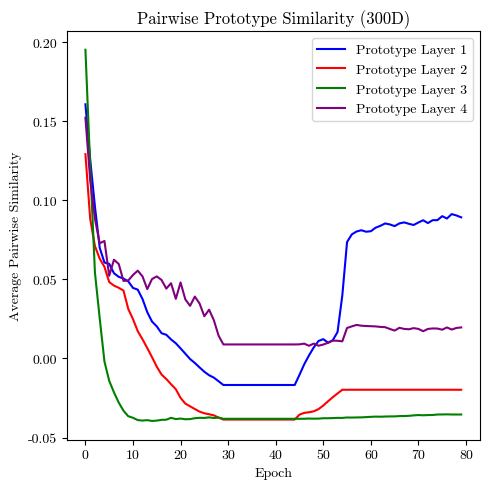

In [ ]:
@torch.no_grad()
def prototype_evolution(dim, n_prototype_layers):

    epoch_sims = [[] for _ in range(n_prototype_layers)]

    for epoch, m in MODELS[dim].items():
        if isinstance(m, nn.DataParallel):
            model = m.module
        else:
            model = m

        epoch_num = int(epoch[5:])

        for layer_idx, prototype_layer in enumerate(model.prototype_layers):
            prototype_vectors = prototype_layer.prototype_vectors
            sim = _pairwise_cos_sim(prototype_vectors, prototype_vectors, eps = 1e-8)

            n = sim.size(0)
            if n < 2:
                return sim.new_tensor(0.0)

            off_diag_mask = ~torch.eye(n, dtype = torch.bool, device = sim.device)
            off_diag = sim[off_diag_mask]
            epoch_sims[layer_idx].append(off_diag.mean().cpu())

    return epoch_sims

fig, ax = plt.subplots(1, len(REPR_DIMS), figsize = (5*len(REPR_DIMS), 5), tight_layout = True)

for i, dim in enumerate(REPR_DIMS):
    sims = prototype_evolution(dim, 4)
    colors = ['blue', 'red', 'green', 'purple']

    for layer_idx, layer_sims in enumerate(sims):
        ax.plot(layer_sims, color = colors[layer_idx], label = f'Prototype Layer {layer_idx + 1}')

    ax.set_title(f'Pairwise Prototype Similarity ({dim}D)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Average Pairwise Similarity')
    ax.legend(loc = 'upper right')

# Dimension Reduced Intermediate Representations

In [ ]:
dr_epochs = [35, 40, 45, 50, 55, 60, 65, 70, 75, 80]

X_test_tensor = torch.tensor(X_test, dtype = torch.float32).to(DEVICE)

with torch.inference_mode():
    for dim in REPR_DIMS:
        for epoch in dr_epochs:
            model = MODELS[dim][f'epoch{epoch}']
            repr_test = model(X_test_tensor).cpu().numpy()
            np.savetxt(f'{SAVE_DIR}/test_reprs_deep/prototsrl{dim}-epoch{epoch}-repr-test.csv', repr_test, delimiter = ',')

In [ ]:
embs = {}

pm = pacmap.PaCMAP(n_components = 3)
for dim in REPR_DIMS:
    embs[dim] = {}
    for epoch in dr_epochs:
        repr = pd.read_csv(f'{SAVE_DIR}/test_reprs_deep/prototsrl{dim}-epoch{epoch}-repr-test.csv', header = None)
        emb = pm.fit_transform(repr)
        embs[dim][epoch] = emb

/tmp/ipykernel_2449/1407133429.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, axs = plt.subplots(


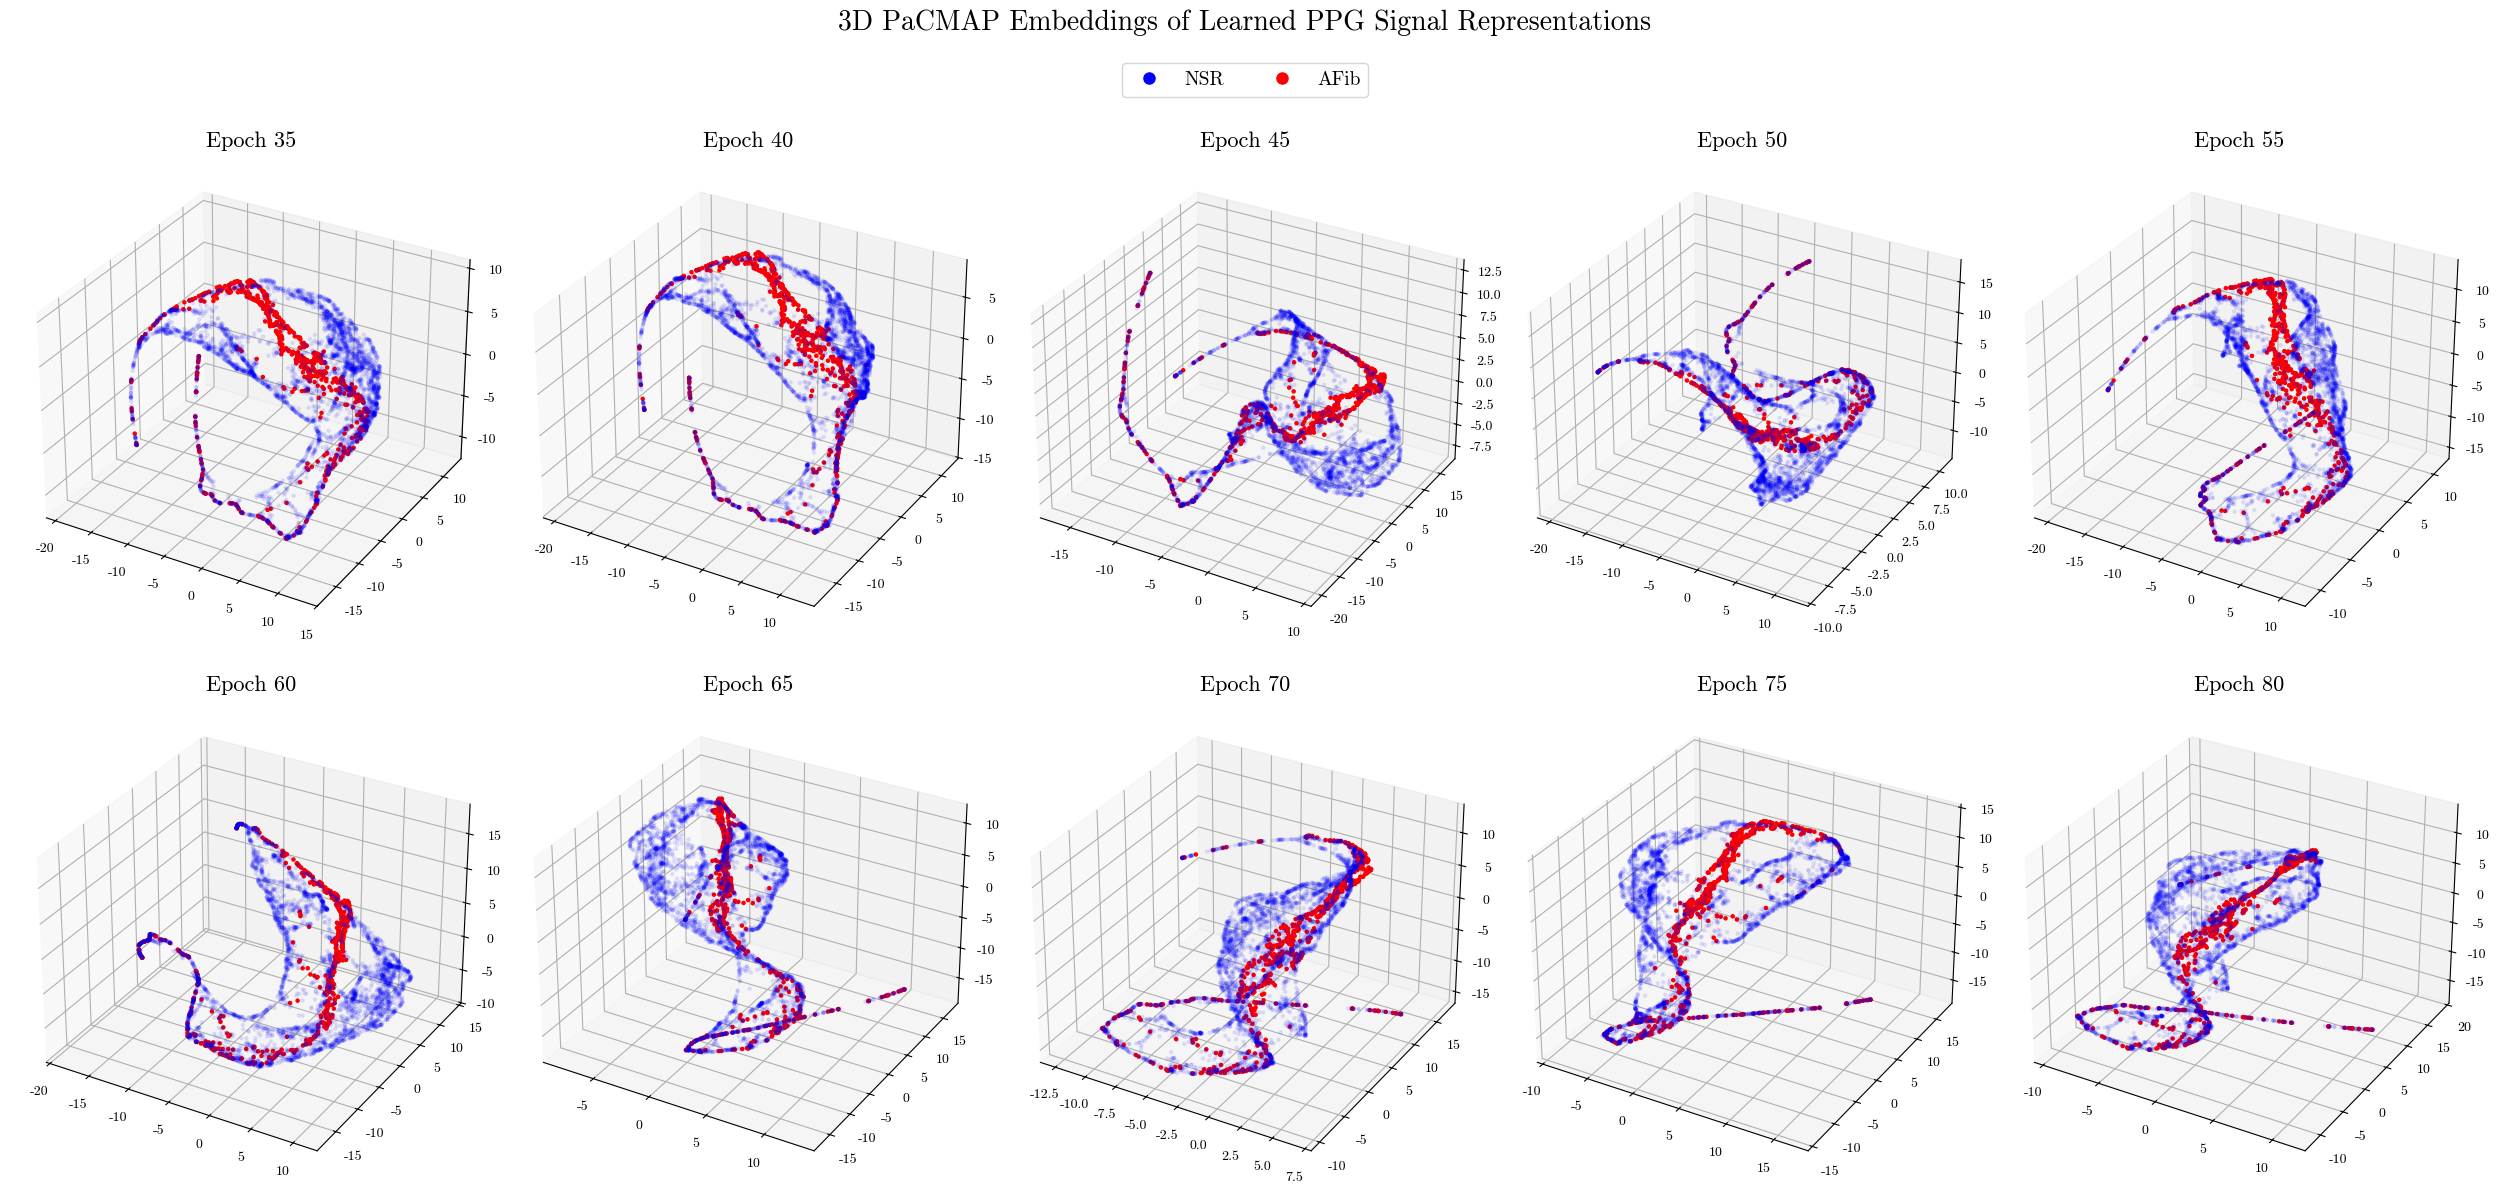

In [ ]:
fig, axs = plt.subplots(
    2, 5,
    figsize = (25, 12.5),
    tight_layout = True,
    subplot_kw = {"projection": "3d"}
)

fig.suptitle("3D PaCMAP Embeddings of Learned PPG Signal Representations", fontsize = 20, y = 1)

class_colors = ['blue', 'red']
class_labels = ["NSR", "AFib"]

for dim in REPR_DIMS:
    for col, epoch in enumerate(dr_epochs):
        emb = embs[dim][epoch]
        ax = axs[col // 5][col % 5]

        for class_value in range(2):
            if class_value == 0:
                alpha = 0.08
            else:
                alpha = 1
            ax.scatter(
                emb[:, 0][y_test == class_value],
                emb[:, 1][y_test == class_value],
                emb[:, 2][y_test == class_value],
                s = 5,
                c = class_colors[class_value],
                alpha = alpha,
                label = class_labels[class_value]
            )

        ax.set_title(f"Epoch {epoch}", fontsize=16)

legend_handles = [
    Line2D(
        [0], [0],
        marker = 'o',
        linestyle = 'None',
        color = class_colors[i],
        markersize = 8,
        label = class_labels[i]
    )
    for i in range(2)
]

fig.legend(
    handles = legend_handles,
    loc = 'upper center',
    bbox_to_anchor = (0.5, 0.965),
    ncol = 2,
    frameon = True,
    fontsize = 14
)

fig.tight_layout(rect = [0, 0, 1, 0.98])

/tmp/ipykernel_2449/3934993803.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, axs = plt.subplots(


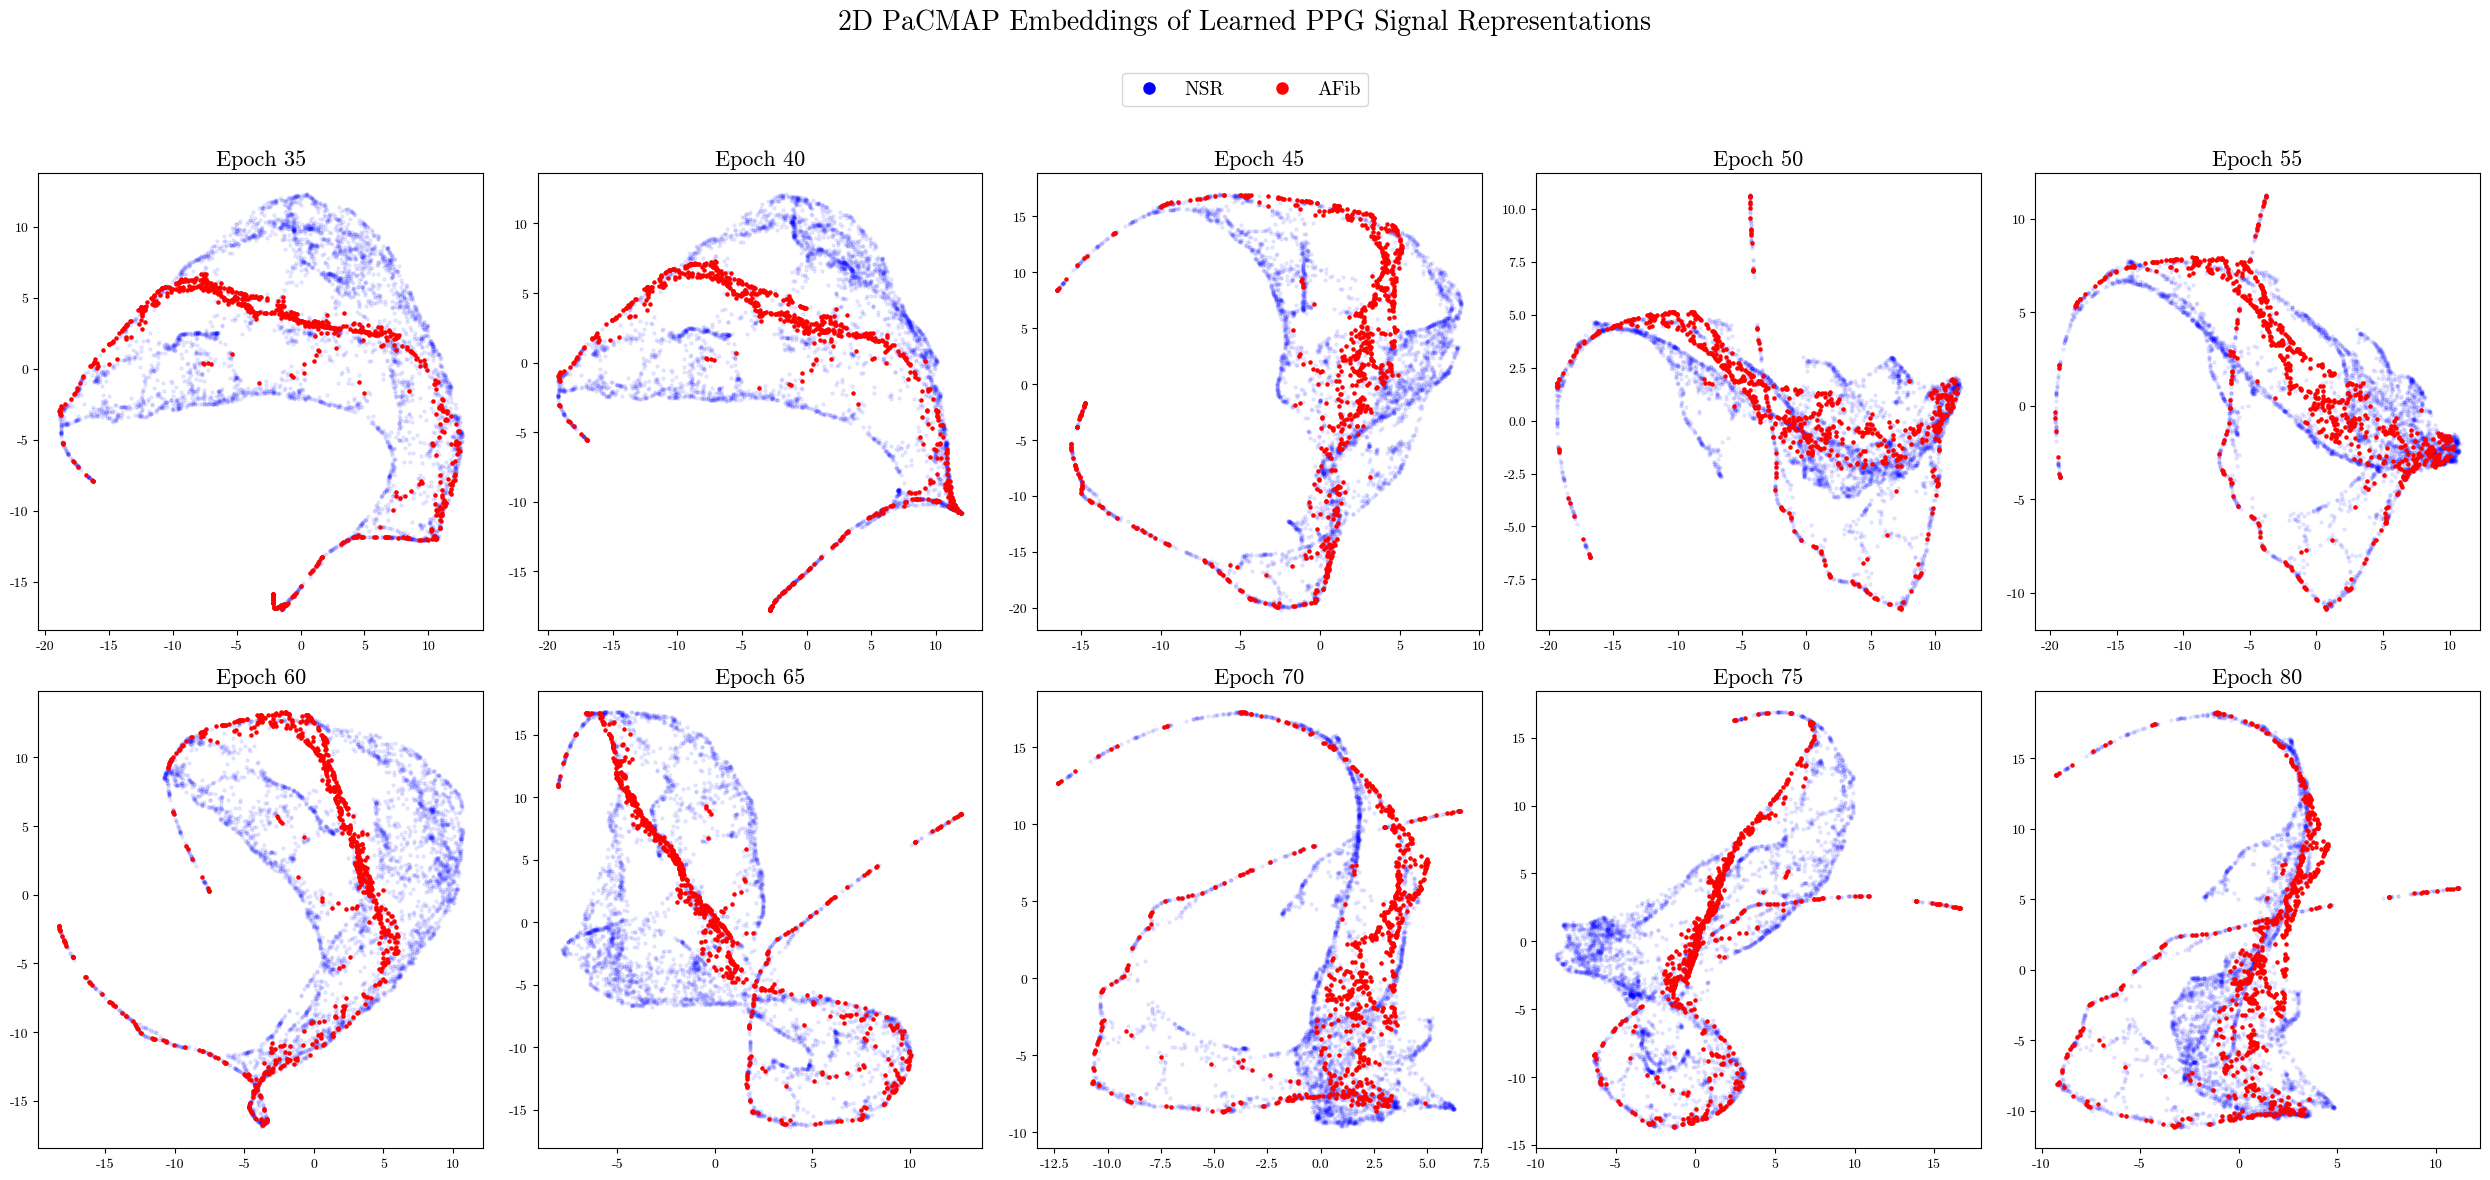

In [ ]:
fig, axs = plt.subplots(
    2, 5,
    figsize = (25, 12),
    tight_layout = True
)

fig.suptitle(
    "2D PaCMAP Embeddings of Learned PPG Signal Representations", fontsize = 20, y = 0.98)

class_colors = ['blue', 'red']
class_labels = ["NSR", "AFib"]

for dim in REPR_DIMS:
    for col, epoch in enumerate(dr_epochs):
        emb = embs[dim][epoch]
        ax = axs[col // 5][col % 5]

        for class_value in range(2):
            if class_value == 0:
                alpha = 0.08
            else:
                alpha = 1
            ax.scatter(
                emb[:, 0][y_test == class_value],
                emb[:, 1][y_test == class_value],
                s = 5,
                c = [class_colors[class_value]],
                alpha = alpha,
                label = class_labels[class_value]
            )

        ax.set_title(f"Epoch {epoch}", fontsize = 16)

legend_handles = [
    Line2D(
        [0], [0],
        marker = 'o',
        linestyle = 'None',
        color = class_colors[i],
        markersize = 8,
        label = class_labels[i]
    )
    for i in range(2)
]

fig.legend(
    handles = legend_handles,
    loc = 'upper center',
    bbox_to_anchor = (0.5, 0.935),
    ncol = 2,
    frameon = True,
    fontsize = 14
)

fig.tight_layout(rect = [0, 0, 1, 0.91])

/tmp/ipykernel_2449/3875655581.py:2: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  ax2d = fig.add_subplot(1, 2, 1)
/tmp/ipykernel_2449/3875655581.py:3: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  ax3d = fig.add_subplot(1, 2, 2, projection = "3d")


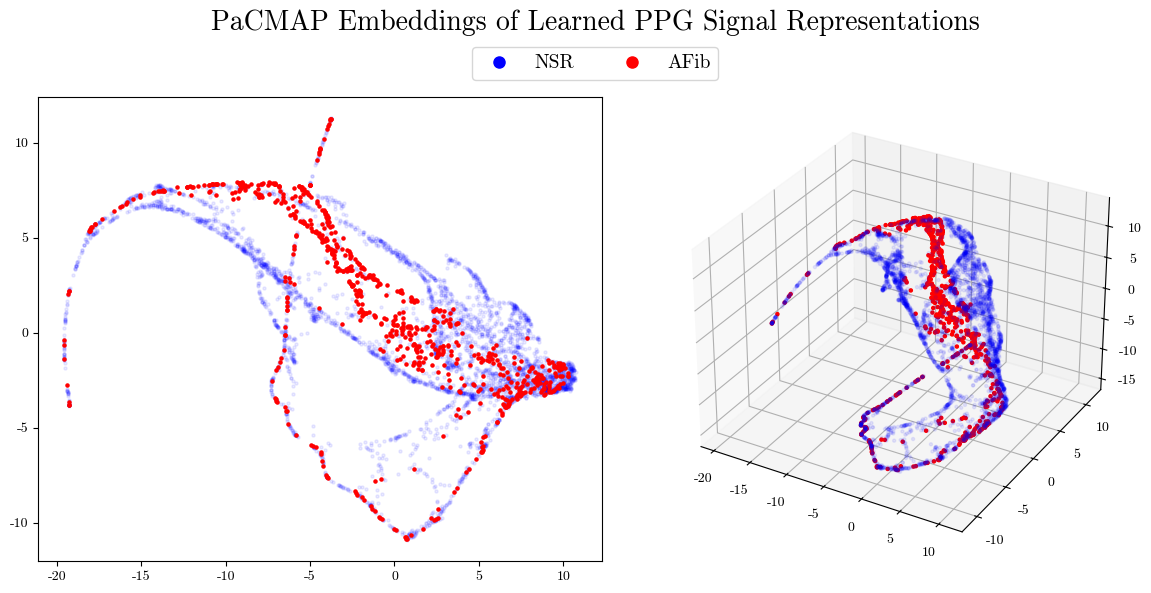

In [ ]:
fig = plt.figure(figsize = (12, 6), tight_layout = True)
ax2d = fig.add_subplot(1, 2, 1)
ax3d = fig.add_subplot(1, 2, 2, projection = "3d")

fig.suptitle("PaCMAP Embeddings of Learned PPG Signal Representations", fontsize = 20, y = 0.98)

class_colors = ['blue', 'red']
class_labels = ["NSR", "AFib"]

emb = embs[300][55]
for class_value in range(2):
    ax2d.scatter(
        emb[:, 0][y_test == class_value],
        emb[:, 1][y_test == class_value],
        s = 5,
        c = [class_colors[class_value]],
        label = class_labels[class_value],
        alpha = 0.08 if class_value == 0 else 1
    )
    ax3d.scatter(
        emb[:, 0][y_test == class_value],
        emb[:, 1][y_test == class_value],
        emb[:, 2][y_test == class_value],
        s = 5,
        c = [class_colors[class_value]],
        label = class_labels[class_value],
        alpha = 0.08 if class_value == 0 else 1
    )

legend_handles = [
    Line2D(
        [0], [0],
        marker = 'o',
        linestyle = 'None',
        color = class_colors[i],
        markersize = 8,
        label = class_labels[i]
    )
    for i in range(2)
]

fig.legend(
    handles = legend_handles,
    loc = 'upper center',
    bbox_to_anchor = (0.5, 0.935),
    ncol = 2,
    frameon = True,
    fontsize = 14
)

fig.tight_layout(rect = [0, 0, 1, 0.93])

/tmp/ipykernel_2449/802044463.py:2: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  ax2d = fig.add_subplot(1, 2, 1)
/tmp/ipykernel_2449/802044463.py:3: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  ax3d = fig.add_subplot(1, 2, 2, projection = "3d")


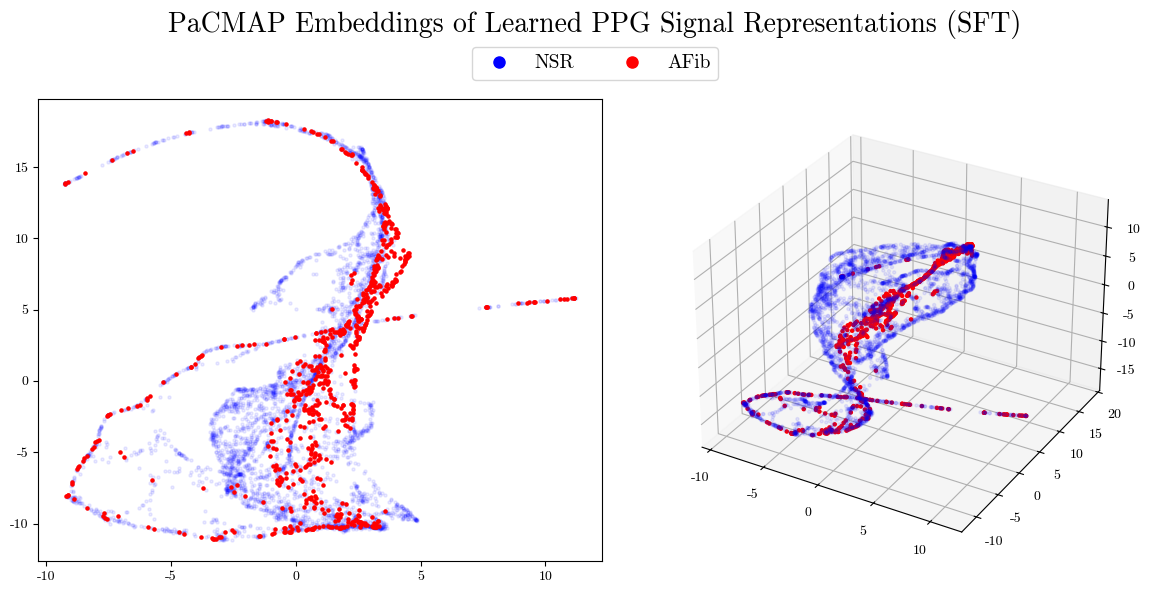

In [ ]:
fig = plt.figure(figsize = (12, 6), tight_layout = True)
ax2d = fig.add_subplot(1, 2, 1)
ax3d = fig.add_subplot(1, 2, 2, projection = "3d")

fig.suptitle("PaCMAP Embeddings of Learned PPG Signal Representations (SFT)", fontsize = 20, y = 0.98)

class_colors = ['blue', 'red']
class_labels = ["NSR", "AFib"]

emb = embs[300][80]
for class_value in range(2):
    ax2d.scatter(
        emb[:, 0][y_test == class_value],
        emb[:, 1][y_test == class_value],
        s = 5,
        c = [class_colors[class_value]],
        label = class_labels[class_value],
        alpha = 0.08 if class_value == 0 else 1
    )
    ax3d.scatter(
        emb[:, 0][y_test == class_value],
        emb[:, 1][y_test == class_value],
        emb[:, 2][y_test == class_value],
        s = 5,
        c = [class_colors[class_value]],
        label = class_labels[class_value],
        alpha = 0.08 if class_value == 0 else 1
    )

legend_handles = [
    Line2D(
        [0], [0],
        marker = 'o',
        linestyle = 'None',
        color = class_colors[i],
        markersize = 8,
        label = class_labels[i]
    )
    for i in range(2)
]

fig.legend(
    handles = legend_handles,
    loc = 'upper center',
    bbox_to_anchor = (0.5, 0.935),
    ncol = 2,
    frameon = True,
    fontsize = 14
)

fig.tight_layout(rect = [0, 0, 1, 0.93])

# Activation Maps

In [6]:
# Reload test data to avoid wait time

X_test, y_test = load_data(
    file_path = '/content/drive/MyDrive/Duke/Senior Year/Thesis/data/',
    clean = INCLUDE_CLEAN_DATA,
    seminoisy = INCLUDE_SEMINOISY_DATA,
    noisy = INCLUDE_NOISY_DATA,
    dataset = 'test',
    return_labels = True
)

X_test = np.transpose(X_test, (0, 2, 1))
X_test_tensor = torch.tensor(X_test, dtype = torch.float32)

m = MODELS[dim]['epoch55']
if isinstance(m, nn.DataParallel):
    model = m.module
else:
    model = m

/tmp/ipykernel_13767/1130615761.py:2: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.plot(np.squeeze(np.transpose(X_test[i])))


Text(0.5, 1.0, '0, False')

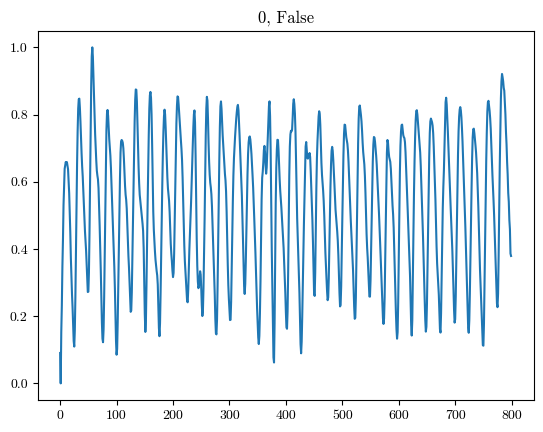

In [45]:
i = 0
plt.plot(np.squeeze(np.transpose(X_test[i])))
plt.title(f'{i}, {y_test[i]}')

In [70]:
@torch.no_grad()
def get_prototype_activations(model, x, device):

    model.eval()
    x = x.to(device)
    out = _extended_forward(model, x)

    return out["a"]

@torch.no_grad()
def overlay_prototype_activation(model, x, proto_layer_idx, proto_idx, device, label, ax):
    acts = get_prototype_activations(model, x, device)
    a = acts[proto_layer_idx][0, proto_idx]

    signal = x[0, 0].detach().cpu()
    T = signal.shape[0]

    # Upsample activation trace to raw signal length
    a_up = F.interpolate(
        a[None, None, :],
        size=T,
        mode="linear",
        align_corners=False
    )[0, 0].cpu()

    # Normalize for display
    a_up = (a_up - a_up.min()) / (a_up.max() - a_up.min() + 1e-8)

    ymin = signal.min().item() - 0.05
    ymax = signal.max().item() + 0.05

    # 1-row heatmap stretched across the full signal height
    heat = a_up.numpy()[None, :]
    im = ax.imshow(
        heat,
        aspect="auto",
        extent=[0, T - 1, ymin, ymax],
        origin="lower",
        cmap="jet",
        alpha=0.4,
        vmin=0.0,
        vmax=1.0,
    )

    ax.plot(signal.numpy(), linewidth=1.0, color="black")
    ax.set_xlim(0, T - 1)
    ax.set_ylim(ymin, ymax)

    if label == 0:
        ax.set_title(f"Prototype ({proto_layer_idx + 1}, {proto_idx}) Activations: NSR", fontsize = 18)
    elif label == 1:
        ax.set_title(f"Prototype ({proto_layer_idx + 1}, {proto_idx}) Activations: AFib", fontsize = 18)

    return im

/tmp/ipykernel_13767/2837094768.py:3: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, axs = plt.subplots(4, 2, figsize = (15, 12), constrained_layout = True)
/tmp/ipykernel_13767/2837094768.py:12: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  cbar = fig.colorbar(


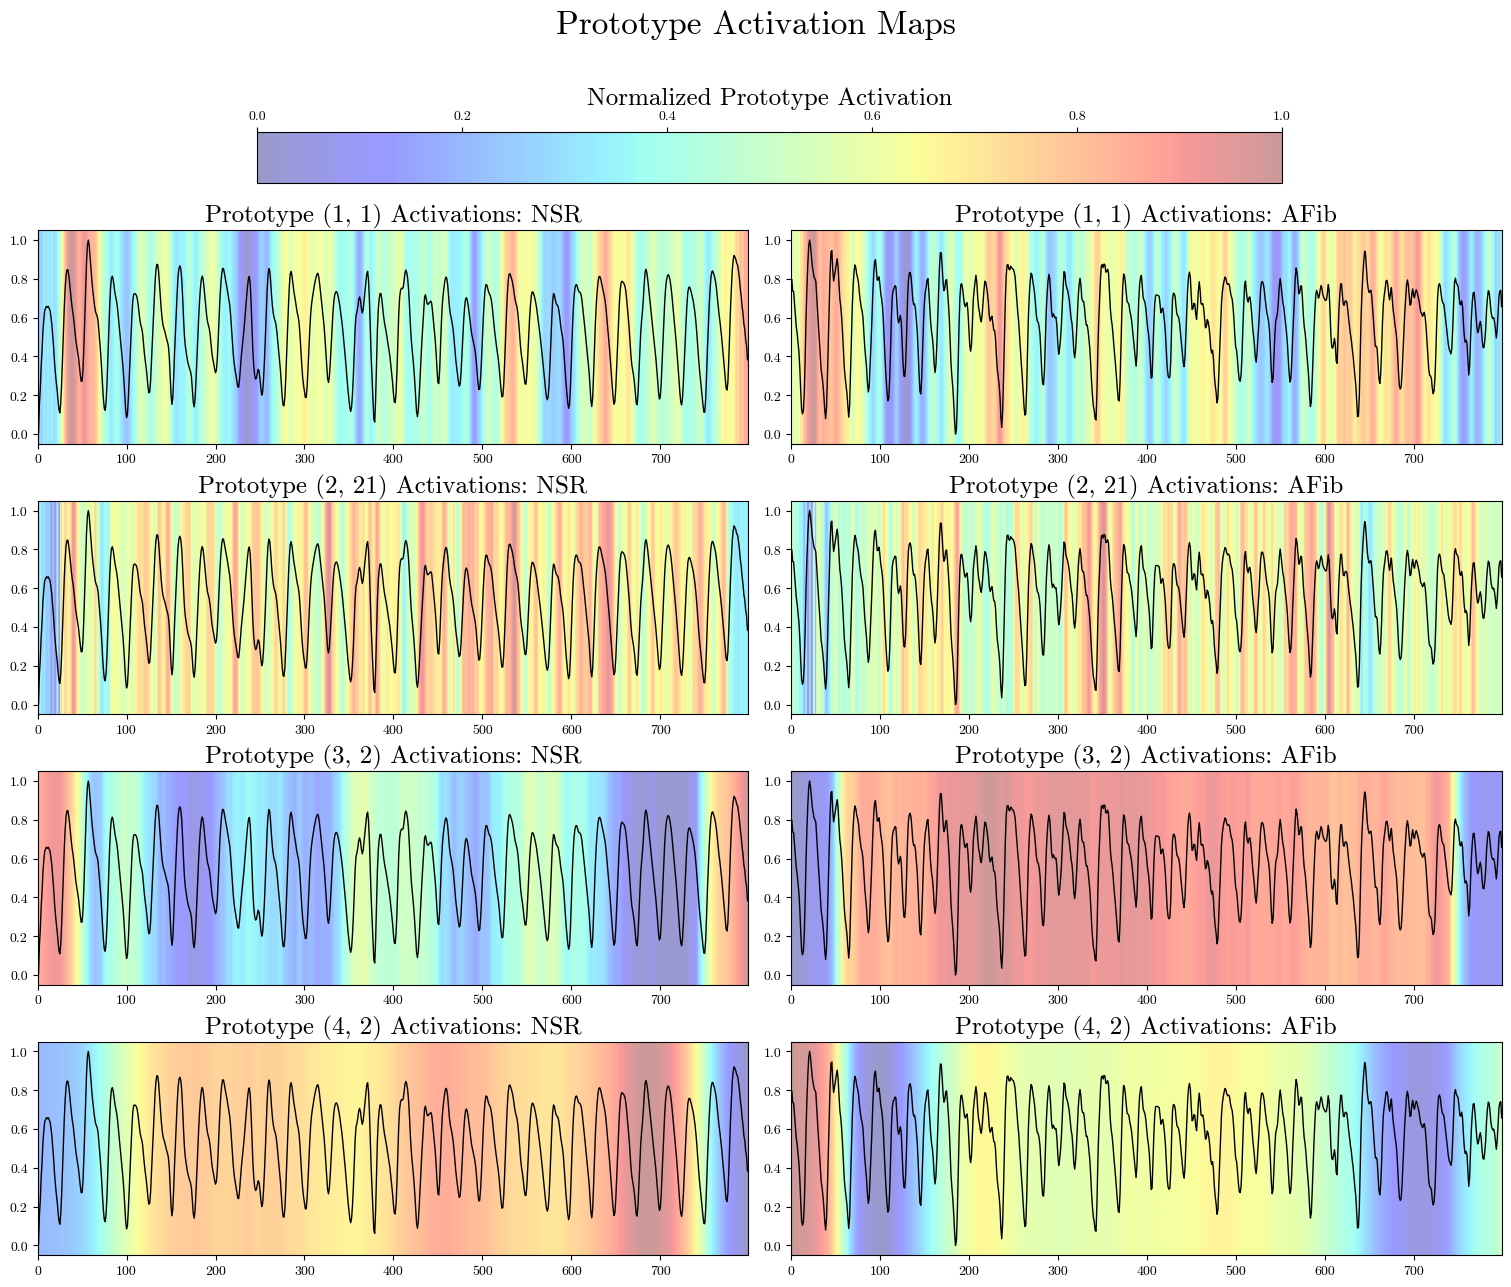

In [71]:
prototypes = [(1, 1), (2, 21), (3, 2), (4, 2)]

fig, axs = plt.subplots(4, 2, figsize = (15, 12), constrained_layout = True)
fig.suptitle('Prototype Activation Maps', fontsize = 24, y = 1.06)
ims = []
row = 0
for proto_layer, proto_idx in prototypes:
    ims.append(overlay_prototype_activation(model, X_test_tensor[0].unsqueeze(0), proto_layer-1, proto_idx, DEVICE, 0, axs[row][0]))
    ims.append(overlay_prototype_activation(model, X_test_tensor[-12].unsqueeze(0), proto_layer-1, proto_idx, DEVICE, 1, axs[row][1]))
    row += 1

cbar = fig.colorbar(
    ims[0],
    ax = axs,
    orientation = "horizontal",
    location = "top",
    pad = 0.02,
    fraction = 0.05,
)
cbar.set_label("Normalized Prototype Activation", fontsize = 18)